
# 05 — Portfolio Volatility Targeting

In Notebook 04 we controlled **risk at the asset level**: each position was sized so that, *in isolation*, it targeted roughly the same annualised volatility.  
This produced sensible relative weights across markets, but it **did not control the risk of the portfolio as a whole**.

In this notebook we add a second, higher-level risk layer.

---

## Objective of this step

We aim to keep the **entire portfolio** close to a fixed annualised volatility target (e.g., 10%), taking correlations between assets into account.

This involves four key steps:

---

### 1) Estimate portfolio risk over time  

We compute a rolling, annualised covariance matrix of asset returns using a fixed lookback window.  
For each date $ t $\)$, this gives us an estimate of the covariance matrix:

$$
\Sigma_t
$$

Using this and our day-$t$ weights from Notebook 04, we estimate the portfolio’s annualised volatility as:

$$
\hat{\sigma}_{p,t}
= \sqrt{ w_t^\top \Sigma_t w_t }
$$

---

### 2) Make the risk estimate tradable  

Because $ \Sigma_t $ is only known **after** day $ t $ closes, we shift the estimated portfolio volatility by one day:

$$
\hat{\sigma}_{p,t-1}
$$

This is the volatility estimate we are allowed to use when sizing trades for day % t %.

---

### 3) Compute a portfolio scaling factor  

We scale all positions up or down together so that the portfolio hits a fixed target volatility:

$$
\text{scale}_t
= \frac{\sigma^*_{\text{portfolio}}}{\hat{\sigma}_{p,t-1}}
$$

- If estimated risk is **too high**, we scale weights down.  
- If estimated risk is **too low**, we scale weights up (within a safety cap).
So we get:

$$
w_{i,t} = sign_{i,t-1} \frac{\sigma_{i,target}}{ \hat{\sigma}_{i,t-1} }  \frac{\sigma_{p,target} }{ \hat{\sigma}_{p,t-1} }
$$
So if we were targeting double the portfolio vol we would double the weights from our asset vol target weights.
$$
w_{i,t} = sign_{i,t-1} \frac{\sigma_{i,target}}{ \hat{\sigma}_{i,t-1} } * 2
$$
as our new portfolio vol will be
$$
\hat{\sigma}_{p,t}
= \sqrt{4 * w_t^\top \Sigma_t w_t }
$$

---

### 4) Apply guardrails  

Two practical safeguards are applied:

- A **cap on the scaling factor** to avoid extreme leverage in early or unstable periods.  
- A **gross exposure cap** to prevent the final portfolio from becoming unreasonably large.

---

## How this fits with Notebook 04

| Layer | What it controls | What it ignores |
|------|-----------------|----------------|
| **04 — Per-asset sizing** | Risk of each individual market | Correlations between markets |
| **05 — Portfolio scaling** | Total portfolio risk | Differences in asset volatilities |

Together, these two layers give us:
- Stable **relative** positions across assets (04), and  
- Stable **overall** risk through time (05).



Imagine two assets:
* Asset A vol = 20%
* Asset B vol = 5%

After 04 (10% per-asset target)
You’d roughly get:
* A weight ≈ 0.5
* B weight ≈ 2.0
So raw gross ≈ 2.5.

But suppose A and B are highly correlated.
Portfolio vol might already be 12%.

Then in 05 you’d scale down a bit to hit 10%.

If instead A and B were uncorrelated, portfolio vol might be only 7%, so 05 would scale up.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from quant.utils.alignment import align_on_index_and_columns
from quant.analytics.correlation import rolling_covariance
from quant.analytics.portfolio_risk import portfolio_vol_series_from_covs
from quant.portfolios.weights import portfolio_vol_target_weights

from quant.config.strategy import (
    TRADING_DAYS,
    COV_WINDOW,
    MIN_PERIODS,
    PORTFOLIO_TARGET_VOL_ANN,
    SCALE_CAP,
    MAX_GROSS,
)

os.chdir("..")

In [2]:
returns = pd.read_parquet("data/processed/prices_simple_returns.parquet")
w = pd.read_parquet("data/derived/weights_vol_target.parquet")

# Align the signal and returns of index and columns
returns, w, audit = align_on_index_and_columns(
    returns,
    w,
    name_a="returns",
    name_b="weight",
    audit=True,
)

=== Alignment audit ===
returns dates: 5,022 | weight dates: 5,022 | Common: 5,022
returns cols : 15 | weight cols : 15 | Common: 15

Dates only in returns: 0
Dates only in weight: 0

Tickers only in returns: 0
Tickers only in weight: 0


In [3]:
# Get rolling covariances
covs = rolling_covariance(
    returns=returns,
    window=COV_WINDOW,
    periods_per_year=TRADING_DAYS,
    min_periods=MIN_PERIODS,
)

print("Num cov matrices:", len(covs))
print("First/last cov date:", min(covs.keys()), max(covs.keys()))

Num cov matrices: 4920
First/last cov date: 2007-05-23 00:00:00 2025-12-31 00:00:00


In [4]:
# Get t-1 portfolio volatility series from covariances and weights
port_vol_ann_tm1 = portfolio_vol_series_from_covs(
    weights=w,
    covs=covs,
    shift=1,
)
port_vol_ann_tm1.dropna().describe()

count    4919.000000
mean        0.442953
std         0.165807
min         0.000000
25%         0.346413
50%         0.438744
75%         0.535509
max         1.111012
dtype: float64

In [5]:
# Rescale our weights to target portfolio volatility / t-1 portfolio volatility
w05 = portfolio_vol_target_weights(
    weights=w,
    port_vol_tm1=port_vol_ann_tm1,
    target_vol=PORTFOLIO_TARGET_VOL_ANN,
    scale_cap=SCALE_CAP,
    max_gross=MAX_GROSS,
)
gross05 = w05.abs().sum(axis=1)
first_trade = gross05[gross05 > 0].index.min()
print("First non-zero weights date:", first_trade)
print("Gross (p5/median/p95):", gross05.quantile([0.05, 0.5, 0.95]).to_dict())
print("Max gross:", float(gross05.max()))

First non-zero weights date: 2007-12-18 00:00:00
Gross (p5/median/p95): {0.05: 0.0, 0.5: 2.196674389166002, 0.95: 3.0000000000000004}
Max gross: 3.0000000000000018


In [6]:
port_vol05_tm1 = portfolio_vol_series_from_covs(weights=w05, covs=covs, shift=1)
print(port_vol05_tm1.dropna().describe())

count    4919.000000
mean        0.093943
std         0.018761
min         0.000000
25%         0.096003
50%         0.099326
75%         0.100936
max         0.150351
dtype: float64


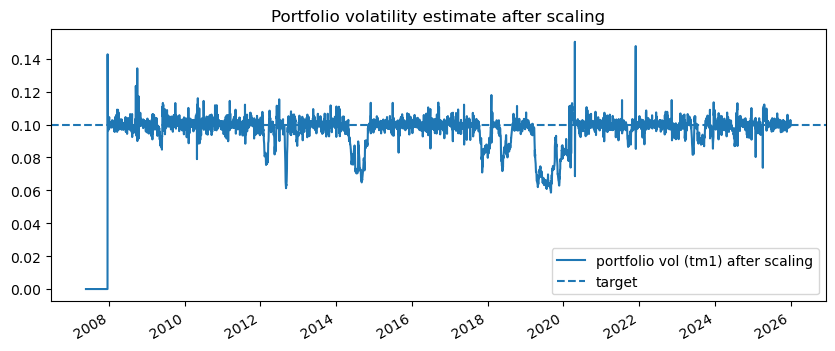

In [7]:
# See how well it is distributed around the target volatility.
# Note that this will not be exact due to the lag and the fact that we are capping the scaling factor and gross exposure, but it should be close.
fig, ax = plt.subplots(figsize=(10, 4))
port_vol05_tm1.plot(ax=ax, label="portfolio vol (tm1) after scaling")
ax.axhline(PORTFOLIO_TARGET_VOL_ANN, linestyle="--", label="target")
ax.set_title("Portfolio volatility estimate after scaling")
ax.legend()
plt.show()

In [8]:
# align our weights to the returns again (important)
returns, w05, _ = align_on_index_and_columns(
    returns, w05, name_a="returns", name_b="w05"
)

port_ret = (w05 * returns).sum(axis=1)
port_ret.name = "portfolio_return"
port_ret.to_frame()

,portfolio_return
2007-01-02,0.000000
2007-01-03,0.000000
2007-01-04,0.000000
2007-01-05,0.000000
2007-01-08,0.000000
...,...
2025-12-25,-0.000108
2025-12-26,0.004454
2025-12-29,-0.008585
2025-12-30,0.000098


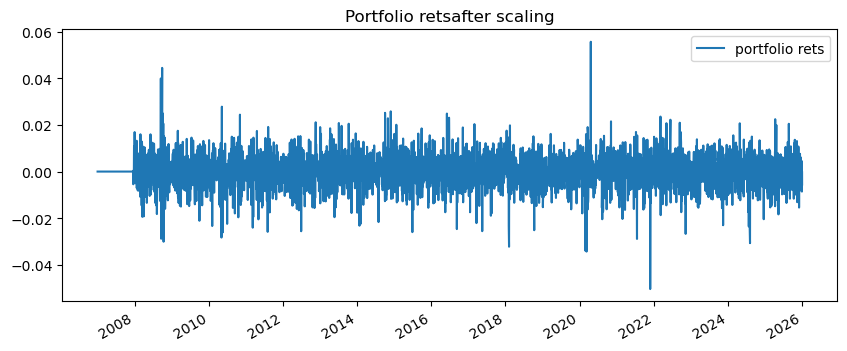

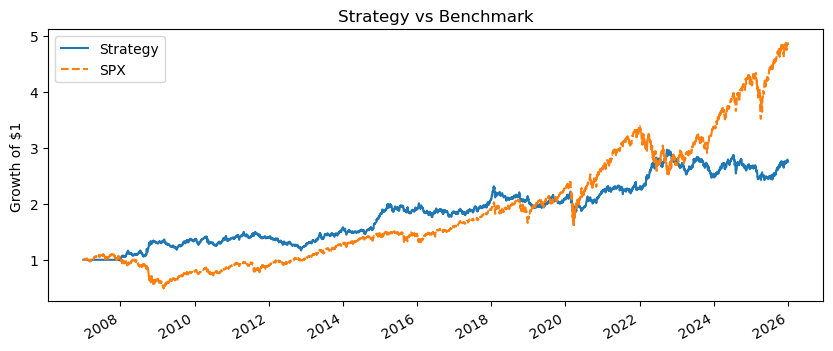

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
port_ret.plot(ax=ax, label="portfolio rets")
ax.set_title("Portfolio retsafter scaling")
ax.legend()
plt.show()

# Convert daily returns to a cumulative index
port_cum = (1 + port_ret).cumprod()

bench_cum = (1 + returns["spx"]).cumprod()

fig, ax = plt.subplots(figsize=(10, 4))
port_cum.plot(ax=ax, label="Strategy")
bench_cum.plot(ax=ax, label="SPX", linestyle="--")
ax.set_title("Strategy vs Benchmark")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.show()

In [10]:
sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)
bench_sharpe = returns["spx"].mean() / returns["spx"].std() * np.sqrt(252)
print(f"Strategy Sharpe: {sharpe:.2f}")
print(f"Benchmark Sharpe: {bench_sharpe:.2f}")

Strategy Sharpe: 0.53
Benchmark Sharpe: 0.51


We baked crisis degence into our model as we have our weights sized based on our rolling vol estimates

$$w_i,t \propto \frac{1}{\hat{\sigma}_{i,t-1}}$$

So any position that jumps in vol will be shrunk. Our built in risk break. We have added in another break at the portfolio level too

$$w_i,t \propto \frac{1}{\hat{\sigma}_{p,t-1}}$$


Strategy clearly Outperformed pre-2019, Defended much better in crises, Then lagged badly from ~2020 onward This is not a bug — it is exactly what we should expect from the type of strategy built.

Why?

Pre-2020 regime (roughly 2007–2019) markets were characterised by:

* Higher volatility
* More frequent drawdowns
* Less persistent mega-cap dominance
* Less structural “tech winner-takes-all” behaviour

In that world, the fund features were strong:

* Multi-asset diversification
* Vol targeting
* Trend signals
* Risk scaling
* Correlation-aware sizing

Why it did well:
* 2008 crisis
* 2011 wobble
* 2015 China scare
* 2018 QT tantrum
strategy is built to thrive in unstable regimes.

SPX crushed strategy post-COVID
* Extreme tech concentration - The S&P 500 became less like “the market” and more like a levered bet on 7 tech companies. SPX succeeded because it accidentally became a concentrated growth fund.
* Vol suppression - Post-COVID markets were characterised by Lower realised vol (after 2020 crash), Central bank backstops, “Buy the dip” regime. In a world where, vol stayed muted, drawdowns are shallow, and growth trends persisted, the defensive mechanics drag performance.


“This strategy delivers equity-like Sharpe with materially better downside protection in stress periods, but structurally underperforms during tech-led, low-volatility bull markets due to diversification and risk controls.”


In [ ]:
w05.to_parquet("data/derived/weights_portfolio_vol_target.parquet")
port_ret.to_frame().to_parquet("data/derived/portfolio_returns.parquet")
port_vol_ann_tm1.to_frame("port_vol_ann_tm1").to_parquet(
    "data/processed/portfolio_vol_ann_tm1_pre.parquet"
)
port_vol05_tm1.to_frame("port_vol_ann_tm1").to_parquet(
    "data/processed/portfolio_vol_ann_tm1.parquet"
)

: 